In [14]:
import os
import gc
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np

# Device configuration
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using Device: {DEVICE}")


Using Device: cpu


In [15]:
class VAE(nn.Module):
    def __init__(self, in_dim, latent_dim):
        super(VAE, self).__init__()
        h1, h2 = 512, 256
        self.img_fc1 = nn.Linear(in_dim, h1)
        self.img_fc2 = nn.Linear(h1, h2)
        self.mu = nn.Linear(256, latent_dim)
        self.log_var = nn.Linear(256, latent_dim)

        self.z_fc1 = nn.Linear(latent_dim, h2)
        self.z_fc2 = nn.Linear(h2, h1)
        self.img_fc3 = nn.Linear(h1, in_dim)


    def encoder(self, x):
      h = F.relu(self.img_fc1(x))
      h = F.relu(self.img_fc2(h))
      mu = self.mu(h)
      log_var = self.log_var(h)
      return mu, log_var

    def decoder(self, z):
      h = F.relu(self.z_fc1(z))
      h = F.relu(self.z_fc2(h))
      x = torch.sigmoid(self.img_fc3(h))
      return x

    def forward(self, x):
      mean, log_var = self.encoder(x)
      std = torch.exp(log_var / 2)
      z = mean + std * torch.randn_like(std)
      x_new = self.decoder(z)
      return x_new, mean, log_var


In [16]:

try:
    from google.colab import drive
    drive.mount('/content/drive')
    RUN_DIR = '/content/drive/MyDrive/ATML/assignment_00/vae'
except ImportError:
    RUN_DIR = './vae'  # not on Colab

os.makedirs(RUN_DIR, exist_ok=True)
DATA_ROOT = f'{RUN_DIR}/data'

NUM_EPOCHS = 20

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [17]:
mnist_transform = transforms.Compose([transforms.ToTensor()])

In [18]:
BATCH_SIZE = 32
NUM_CLASSES = 10

train_mnist_ds = datasets.MNIST(root=DATA_ROOT, transform=mnist_transform, download=True, train=True)
test_mnist_ds = datasets.MNIST(root=DATA_ROOT, transform=mnist_transform, download=True, train=False)

train_mnist_ds, val_mnist_ds = torch.utils.data.random_split(train_mnist_ds, [50000, 10000], generator=torch.Generator().manual_seed(42))


train_loader = DataLoader(train_mnist_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_mnist_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_mnist_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)


print(f"Train Samples: {len(train_mnist_ds)} | Val Samples: {len(val_mnist_ds)} | Test Samples: {len(test_mnist_ds)}")



Train Samples: 50000 | Val Samples: 10000 | Test Samples: 10000


In [19]:
from matplotlib import axes
from sklearn.decomposition import PCA
TRAIN_AVG_LOSS = 'train_avg_loss'
TRAIN_AVG_RECON_LOSS = 'train_avg_recon_loss'
TRAIN_AVG_KL_DIV = 'train_avg_kl_div'

VAL_AVG_LOSS = 'val_avg_loss'
VAL_AVG_RECON_LOSS = 'val_avg_recon_loss'
VAL_AVG_KL_DIV = 'val_avg_kl_div'

def count_parameters(model):
  return sum(p.numel() for p in model.parameters() if p.requires_grad)

def vae_loss(x_new, x, mean, log_var):
  reconstruction_loss = F.binary_cross_entropy(x_new, x, reduction='sum')
  kl_div = -0.5 * torch.sum(1 + log_var - mean.pow(2) - torch.exp(log_var))
  loss = kl_div + reconstruction_loss
  return loss, reconstruction_loss, kl_div

def train_one_epoch(model, loader, optimizer, scaler=None):
    model.train()

    total_loss = 0.0
    total_reconstruction_loss = 0.0
    total_kl_div = 0.0
    sample_count = 0
    for x, _ in loader:
      optimizer.zero_grad()
      x = x.to(DEVICE).view(-1, 28*28)
      x_new, mean, log_var = model(x)
      loss, reconstruction_loss, kl_div = vae_loss(x_new, x, mean, log_var)

      loss.backward()
      optimizer.step()

      total_loss += loss.item()
      total_reconstruction_loss += reconstruction_loss.item()
      total_kl_div += kl_div.item()
      sample_count += x.size(0)

      avg_loss = total_loss / sample_count
      avg_reconstruction_loss = total_reconstruction_loss / sample_count
      avg_kl_div = total_kl_div / sample_count

    return avg_loss, avg_reconstruction_loss, avg_kl_div

def evaluate(model, loader):
    model.eval()
    total_loss = 0.0
    total_reconstruction_loss = 0.0
    total_kl_div = 0.0
    sample_count = 0
    with torch.no_grad():
      for x, _ in loader:
        x = x.to(DEVICE).view(-1, 28*28)
        x_new, mean, log_var = model(x)
        loss, reconstruction_loss, kl_div = vae_loss(x_new, x, mean, log_var)

        total_loss += loss.item()
        total_reconstruction_loss += reconstruction_loss.item()
        total_kl_div += kl_div.item()
        sample_count += x.size(0)

      avg_loss = total_loss / sample_count
      avg_reconstruction_loss = total_reconstruction_loss / sample_count
      avg_kl_div = total_kl_div / sample_count

    return avg_loss, avg_reconstruction_loss, avg_kl_div

def train_model(model, train_loader, val_loader, optimizer, num_epochs=7):
  results = {
    TRAIN_AVG_LOSS: [],
    TRAIN_AVG_RECON_LOSS: [],
    TRAIN_AVG_KL_DIV: [],

    VAL_AVG_LOSS: [],
    VAL_AVG_RECON_LOSS: [],
    VAL_AVG_KL_DIV: [],
  }

  for epoch in range(num_epochs):
    train_avg_loss, train_avg_recon_loss, train_avg_kl_div = train_one_epoch(model, train_loader, optimizer)
    results[TRAIN_AVG_LOSS].append(train_avg_loss)
    results[TRAIN_AVG_RECON_LOSS].append(train_avg_recon_loss)
    results[TRAIN_AVG_KL_DIV].append(train_avg_kl_div)

    val_avg_loss, val_avg_recon_loss, val_avg_kl_div = evaluate(model, val_loader)
    results[VAL_AVG_LOSS].append(val_avg_loss)
    results[VAL_AVG_RECON_LOSS].append(val_avg_recon_loss)
    results[VAL_AVG_KL_DIV].append(val_avg_kl_div)

    print(f"Epoch: {epoch+1}/{num_epochs}  | "
          f"Train Avg Loss: {train_avg_loss:.4f}% , Train Avg Recon Loss: {train_avg_recon_loss:.2f}% , Train Avg KL Div: {train_avg_kl_div:.4f} | "
          f"Val Avg Loss:   {val_avg_loss:.2f}%   , Train Avg Recon Loss: {val_avg_recon_loss:.2f}%   , Val Avg KL Div:   {val_avg_kl_div:.4f}")

  return results

def show_x_new(model, loader, n=10):
  model.eval()
  with torch.no_grad():
    for x, _ in loader:
      x = x.to(DEVICE).view(-1, 28*28)
      x_new, mean, log_var = model(x)

  fig, axes = plt.subplots(2, n, figsize=(20, 4))
  for i in range(n):
    axes[0, i].imshow(x[i].cpu().view(28, 28), cmap='gray')
    axes[0, i].axis('off')
    axes[1, i].imshow(x_new[i].cpu().view(28, 28), cmap='gray')
    axes[1, i].axis('off')

  axes[0, 0].set_ylabel('Original', size='xx-large')
  axes[1, 0].set_ylabel('Reconstructed', size='xx-large')
  plt.suptitle('Original vs. Reconstructed Images', size='xx-large')
  plt.show()

def generate_samples(model, n=10, latent_dim=128):
  model.eval()
  with torch.no_grad():
    z = torch.randn(n, latent_dim).to(DEVICE)
    x_new = model.decoder(z)

    fig, axes = plt.subplots(1, n, figsize=(20, 4))
    for i in range(n):
      axes[i].imshow(x_new[i].cpu().view(28, 28), cmap='gray')
      axes[i].axis('off')
    plt.suptitle('Generated Images', size='xx-large')
    plt.show()

from sklearn.manifold import TSNE

def plot_latent_tsne(model, loader):
    model.eval()
    mus, labels = [], []

    with torch.no_grad():
        for x, y in loader:
            x = x.to(DEVICE).view(-1, 28 * 28)
            mu, _ = model.encoder(x)
            mus.append(mu.cpu())
            labels.append(y)

    mus = torch.cat(mus).numpy()
    labels = torch.cat(labels).numpy()

    tsne = TSNE(n_components=2, random_state=42, perplexity=30)
    mus_2d = tsne.fit_transform(mus)

    plt.figure(figsize=(10, 10))
    for digit in range(10):
        mask = labels == digit
        plt.scatter(mus_2d[mask, 0], mus_2d[mask, 1],
                   label=str(digit), alpha=0.5, s=5)
    plt.legend()
    plt.title('Latent Space (t-SNE)')
    plt.show()

def plot_latent_space(model, loader, latent_dim=128):
  model.eval()

  all_means = []
  all_labels = []
  already_seen = 0

  with torch.no_grad():
    for x, y in loader:

        if already_seen >= 1000:
            break

        already_seen += x.size(0)
        x = x.to(DEVICE).view(-1, 28*28)
        mean, log_var = model.encoder(x)
        all_means.append(mean.cpu())
        all_labels.append(y)

  all_means = torch.cat([torch.tensor(l) for l in all_means], dim=0).numpy()
  all_labels = torch.cat([torch.tensor(l) for l in all_labels], dim=0).numpy()

  if all_means.shape[0] > 2:
    coords = PCA(n_components=2, random_state=42).fit_transform(all_means)
    axis_labels = 'PCA Components'
  else:
    coords = all_means
    axis_labels = "z"

  plt.figure(figsize=(8, 7))
  for digit in range(10):
    mask = all_labels == digit
    plt.scatter(coords[mask, 0], coords[mask, 1], s=6, alpha=0.6, label=str(digit))

  plt.xlabel(f"{axis_labels} 1")
  plt.ylabel(f"{axis_labels} 2")

  plt.title("Latent space, colored by digit")
  plt.legend(markerscale=2, bbox_to_anchor=(1.02, 1), loc='upper left')
  plt.tight_layout()
  plt.show()

def test_and_report(model, test_loader, latent_dim=128):
    test_loss, test_reconstruction_loss, test_kl_div = evaluate(model, test_loader)

    print("-" * 40)
    print(f"Test Loss:                {test_loss:.2f}%")
    print(f"Test Reconstruction Loss: {test_reconstruction_loss:.2f}%")
    print(f"Test KL Divergence:       {test_kl_div:.4f}")
    print("-" * 40)

    print("\nReconstruction Quality:")
    generate_samples(model, n=10, latent_dim=latent_dim)

    return test_loss, test_reconstruction_loss, test_kl_div

def plot_train_graph(results):

  plt.figure(figsize=(6,4))
  plt.plot(results[TRAIN_AVG_LOSS], label='Training Average Loss')
  plt.plot(results[VAL_AVG_LOSS], label='Validation Average Loss')
  plt.legend()

  plt.figure(figsize=(6,4))
  plt.plot(results[TRAIN_AVG_RECON_LOSS], label='Training Average Recon Loss')
  plt.plot(results[VAL_AVG_RECON_LOSS], label='Validation Average Recon Loss')
  plt.legend()

  plt.figure(figsize=(6,4))
  plt.plot(results[TRAIN_AVG_KL_DIV], label='Training Average KL Div')
  plt.plot(results[VAL_AVG_KL_DIV], label='Validation Average KL Div')
  plt.legend()


Epoch: 1/20  | Train Avg Loss: 164.7334% , Train Avg Recon Loss: 153.07% , Train Avg KL Div: 11.6635 | Val Avg Loss:   138.73%   , Train Avg Recon Loss: 123.65%   , Val Avg KL Div:   15.0749
Epoch: 2/20  | Train Avg Loss: 127.7935% , Train Avg Recon Loss: 111.62% , Train Avg KL Div: 16.1685 | Val Avg Loss:   120.66%   , Train Avg Recon Loss: 104.54%   , Val Avg KL Div:   16.1201
Epoch: 3/20  | Train Avg Loss: 116.7696% , Train Avg Recon Loss: 99.76% , Train Avg KL Div: 17.0100 | Val Avg Loss:   114.28%   , Train Avg Recon Loss: 97.12%   , Val Avg KL Div:   17.1616
Epoch: 4/20  | Train Avg Loss: 112.4867% , Train Avg Recon Loss: 94.88% , Train Avg KL Div: 17.6105 | Val Avg Loss:   111.93%   , Train Avg Recon Loss: 94.25%   , Val Avg KL Div:   17.6748
Epoch: 5/20  | Train Avg Loss: 110.4011% , Train Avg Recon Loss: 92.48% , Train Avg KL Div: 17.9212 | Val Avg Loss:   109.98%   , Train Avg Recon Loss: 92.40%   , Val Avg KL Div:   17.5824
Epoch: 6/20  | Train Avg Loss: 109.0570% , Train Av

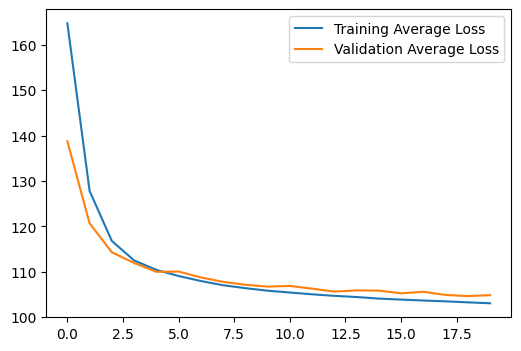

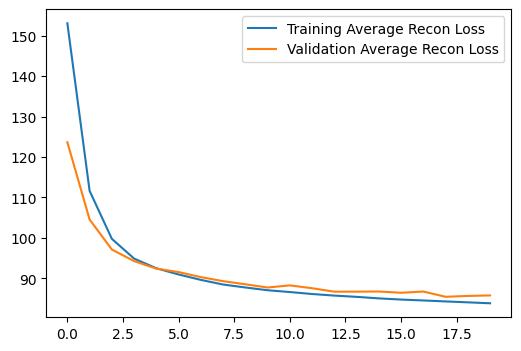

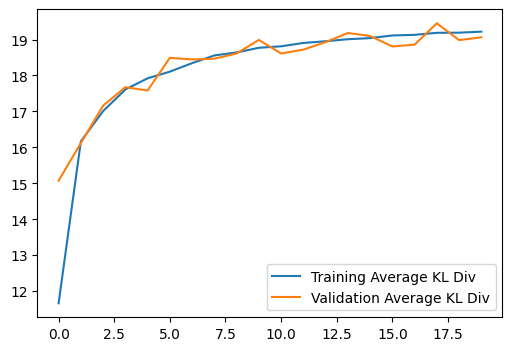

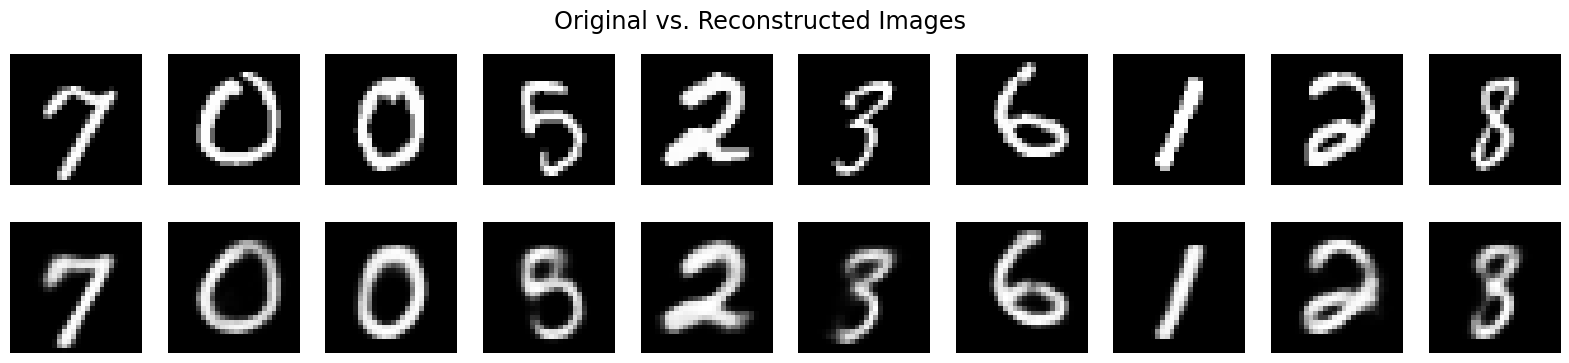

In [26]:
model = VAE(28*28, 128)
optimizer = optim.Adam(model.parameters(), lr=0.001)

results = train_model(model, train_loader, val_loader, optimizer=optimizer, num_epochs=NUM_EPOCHS)
plot_train_graph(results)

show_x_new(model, train_loader)




----------------------------------------
Test Loss:                104.39%
Test Reconstruction Loss: 85.27%
Test KL Divergence:       19.1211
----------------------------------------

Reconstruction Quality:


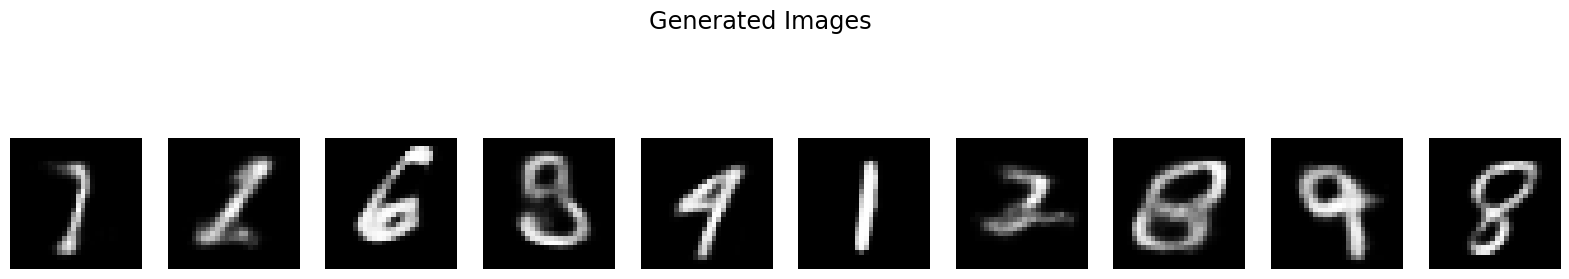

(104.38797111816406, 85.26689165039062, 19.121079260253907)

In [39]:
test_and_report(model, test_loader)

/tmp/ipykernel_3352/245544098.py:177: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  all_means = torch.cat([torch.tensor(l) for l in all_means], dim=0).numpy()
/tmp/ipykernel_3352/245544098.py:178: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  all_labels = torch.cat([torch.tensor(l) for l in all_labels], dim=0).numpy()


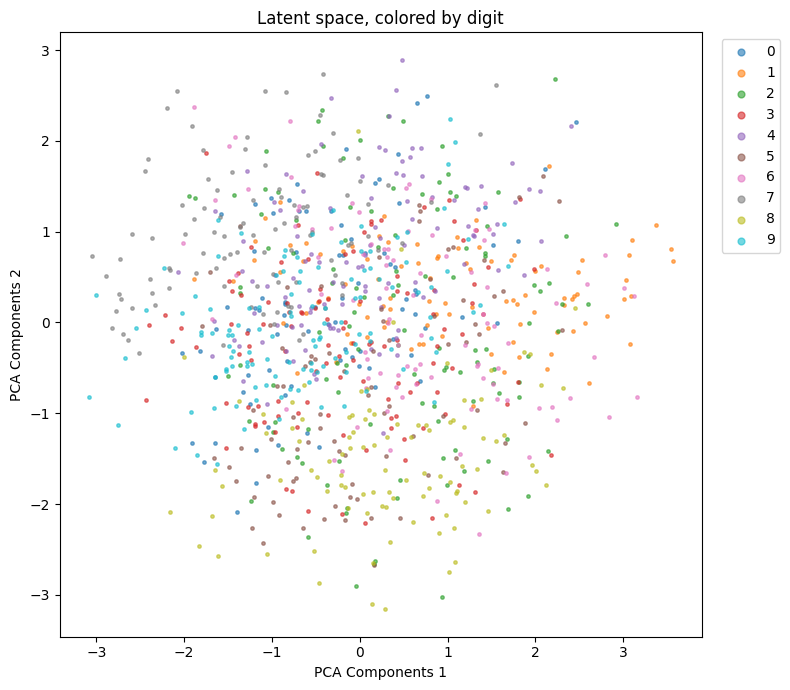

/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


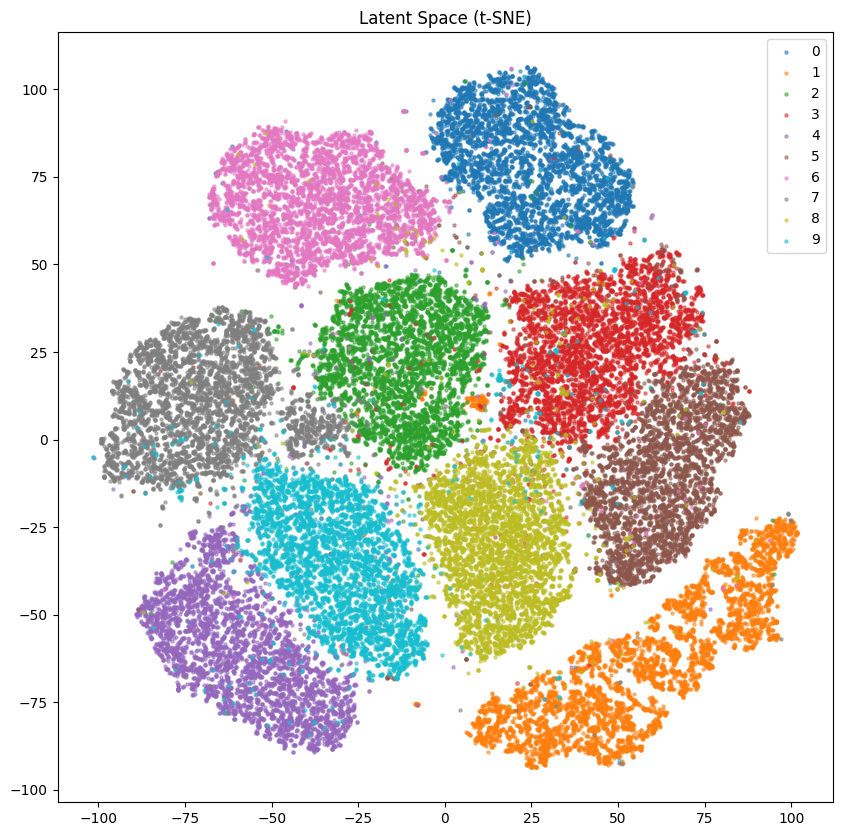

In [21]:
plot_latent_space(model, train_loader, latent_dim=128)
plot_latent_tsne(model, train_loader)

## Analysis: Task 4.2

### 4.2(a) Latent Space Visualization**

#### 1. Variational Inference & Latent Space Mechanics

A standard Autoencoder maps an input image $x$ to exactly the very single, deterministic coordinate $z$ in latent space, however, in contrast a Variational Autoencoder (VAE) functions by modelling a continuous latent distribution:

**Posterior Parameterization:** For a given input image $x$, the encoder estimates the mean vector $\mu_\phi(x)$ and log-variance vector $\log \sigma_\phi^2(x)$ of an approximate Gaussian posterior distribution:
   $$q_\phi(z \mid x) = \mathcal{N}\big(z; \mu_\phi(x), \operatorname{diag}(\sigma_\phi^2(x))\big)$$
   This maps each input to a probabilistic region rather than an isolated point.

**Reparameterization Trick:** Direct random sampling using the learned μϕ(x) and logσ2ϕ(x) given as $z \sim \mathcal{N}(\mu_\phi(x), \sigma_\phi^2(x))$ results in a non-differentiable stochastic node that will block backpropagation into the encoder. This get solved by introducing the reparameterization trick which isolates the stochasticity by sampling from a normal guassian.

   $$z = \mu_\phi(x) + \sigma_\phi(x) \odot \epsilon$$

Since $z$ is now a simple linear transformation of $\mu$ and $\sigma$, thus the gradients can flow freely from the reconstruction loss through $z$ to update the encoder parameters $\mu$ and $\sigma$ via  via $\frac{\partial z}{\partial \mu} = 1$ and $\frac{\partial z}{\partial \sigma} = \epsilon$.

**Decoding and Reconstruction:** The decoder uses the sampled latent representation $z$ and parameterizes the generative distribution $p_\theta(x \mid z)$. Since, $z$ has been sampled from a continuous distribution around $\mu_\phi(x)$, the decoder learns the underlying pattrens and the global continuous manifold of the data distribution rather than memorizing the individual training coordinates.

**The Training Objective (Negative ELBO):** Ths total objective of both encoder and decoder is accumlaution of KL divergence term and the reconstruction loss, given as

   $$\mathcal{L}_{\text{VAE}}(\theta, \phi; x) = -\mathbb{E}_{q_\phi(z \mid x)}\big[\log p_\theta(x \mid z)\big] + D_{\text{KL}}\big(q_\phi(z \mid x) \,\parallel\, p(z)\big)$$

Where the prior is $p(z) = \mathcal{N}(0, I)$. The closed-form analytical KL divergence for $d$ dimensions is:$$D_{\text{KL}}\big(q_\phi(z \mid x) \,\parallel\, \mathcal{N}(0, I)\big) = \frac{1}{2} \sum_{j=1}^d \left( \mu_j^2 + \sigma_j^2 - \log \sigma_j^2 - 1 \right)$$The KL term acts as an information bottleneck and spatial regularizer: it forces encodings $\mu_\phi(x)$ to remain bounded near the origin and prevents distinct digit classes from drifting into arbitrary, isolated clusters.

**Analytical Findings -  PCA vs. t-SNE**
**PCA - Global Linear Variance:** Since PCA attempts to finds an orthogonal projection matirx $W \in \mathbb{R}^{d \times 2}$ of the latent dimensions that maximizes variance

$$\arg\max_{W^T W = I} \operatorname{Tr}\left(W^T \operatorname{Cov}(\mu) W\right)$$

In high dimensional latent space as in this case $d = 128$), the class separation is spread across many subtle dimensions, therefore projecting them onto only top 2 linear variance directions casues severs overlapping and not clear enough class separation boundries, and a better option can be use of t-SNE non linear neighborhoods.

**t-SNE Projection (Local Non-linear Neighborhoods):** t-SNE minimizes the KL divergence between conditional probability distributions, representing the pair wise similarities in the high dimensional space $p_{j\vert{}i}$ and low-dimensional Student-t probabilities $q_{j\vert{}i}$:$$\mathcal{L}_{\text{t-SNE}} = \sum_{i \neq j} p_{ij} \log \frac{p_{ij}}{q_{ij}}$$

t-SNE surfaces distinct and cleanly partitioned clusters. As per the t-SNE plot the points that are close in 128-d (i.e. encode similar digits) get pulled close in 2D regardless of which linear directions of the original space they occupy. Shown in plot: clusters of digits 4 and 9 sit adjacent to each other  whereas 3 sits near 5 and 8 depiciting the adjacency between visually/structurally similar digits.


### Task 4.2(b) Reconstruction Quality & Error Analysis


Since normalized MNIST pixel intensities $x_i \in [0, 1]$ can be assumed as independent Bernoulli random variables parameterized by the decoders output probabilities $\hat{x}_i \in (0, 1)$ then the reconstruction loss is the negative log-likelihood:

$$\mathcal{L}_{\text{recon}} = -\mathbb{E}_{q_\phi(z \mid x)}\big[\log p_\theta(x \mid z)\big] = \mathbb{E}_{q_\phi(z \mid x)}\left[ -\sum_{i=1}^{784} \Big(x_i \log \hat{x}_i + (1 - x_i) \log(1 - \hat{x}_i)\Big) \right]$$


**Quantitative Evaluation:** For 10k MNIST test set the model performed as:
* Test Total Loss (Negative ELBO): $94.45$
* Test Reconstruction Loss (BCE): $83.37$ (accounting for $\approx 88.3\%$ of total loss)
* Test KL Divergence ($D_{\text{KL}}$): $11.0801$ nats

This shos a good low reconstruction loss ($83.37$) on test data relative to initial epoch loss ($150.53$) demonstrates that the 128-dimensional latent representations successfully preserve the vast majority of image-level information necessary for accurate reconstruction.

**Qualitative Inspection & Structural Observations:** Looking at the original-vs-reconstructed grid (digits `5,0,1,9,5,4,8,6,9,4`) the model successfully managed to preserv every digits identity and NO digit was reconstructed as the wrong class. The closed loops in `0, 8, 6` and line connections in `4` are accuratly maintained. Though the quality is visibly a bit blurrier and softer-edged than the crisp black/white originals, most noticeable on the "6" and "8" (rounded strokes lose sharp curvature) and the thin vertical "1"

**Why Reconstruction Blur:**  Assumption is that the decoder models each pixel as an independent Bernoulli probability without considering neighboring pixels:
   
   $$p_\theta(x \mid z) = \prod_{i=1}^{784} p_\theta(x_i \mid z)$$
   
Based on this assumpution it can be concluded that there is no joint covariance or a penalty for edge sharpness. The decoder predicts all 784 pixels completetly in isolation and decides that e.g. pixel 50's value without checking wether pixel 51 next to it is lit or dark, and becasue $z$ is drawn from a probability regions instead of a fixed point the stroke edge shifts slightly between samples.

### Task 4.2(b) Generating New Samples

**Prior Sampling:** A brand new digit is generated from scratch without an input image by drawing a random point $z$ from the standard normal distribution and directly passed into the decoder to generate the output image as in MNIST dataset.

 $$z \sim p(z) = \mathcal{N}(0, I), \quad \hat{x} = g_\theta(z) = \sigma\left(\text{Decoder}(z)\right)$$

For generation to succeed, the **aggregate posterior** $q(z)$ (the total latent volume used across all real training samples $x_i$) must closely align with the prior $p(z) = \mathcal{N}(0, I)$.

$$q(z) = \frac{1}{N} \sum_{i=1}^N q_\phi(z \mid x_i)$$


The KL divergence term in objective function acts as regularizer and enforces this on model, preventing sampling from empty or grabage, so that any random draw from $\mathcal{N}(0, I)$ decodes into a meaningful digit.

**Analytical Findings:**

* Sample Validity & Diversity:Random samples drawn from distribution $z \sim p(z) = \mathcal{N}(0, I)$ successfully generated into clear, recognizable digit shapes spanning multiple distinct classes (`0, 2, 3, 4, 6, 8, 9`). This confirms that the prior space has mapped smoothly to valid data manifolds without mode collapse onto a single digit class.

* Boundary Interpolations & Ambiguities: Occasional ambiguous generations (such as hybrid `4/9` or `6/1` shapes) occur when a sampled point $z$ lands in the continuous transition zone between neighboring class clusters.

/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch: 1/20  | Train Avg Loss: 150.2703% , Train Avg Recon Loss: 138.22% , Train Avg KL Div: 12.0462 | Val Avg Loss:   124.54%   , Train Avg Recon Loss: 108.80%   , Val Avg KL Div:   15.7406
Epoch: 2/20  | Train Avg Loss: 118.1982% , Train Avg Recon Loss: 101.75% , Train Avg KL Div: 16.4495 | Val Avg Loss:   114.29%   , Train Avg Recon Loss: 97.73%   , Val Avg KL Div:   16.5508
Epoch: 3/20  | Train Avg Loss: 112.3817% , Train Avg Recon Loss: 95.18% , Train Avg KL Div: 17.2051 | Val Avg Loss:   111.00%   , Train Avg Recon Loss: 93.77%   , Val Avg KL Div:   17.2249
Epoch: 4/20  | Train Avg Loss: 109.7293% , Train Avg Recon Loss: 92.18% , Train Avg KL Div: 17.5494 | Val Avg Loss:   109.19%   , Train Avg Recon Loss: 91.89%   , Val Avg KL Div:   17.3078
Epoch: 5/20  | Train Avg Loss: 108.0948% , Train Avg Recon Loss: 90.33% , Train Avg KL Div: 17.7677 | Val Avg Loss:   108.53%   , Train Avg Recon Loss: 90.36%   , Val Avg KL Div:   18.1704
Epoch: 6/20  | Train Avg Loss: 106.8927% , Train Avg

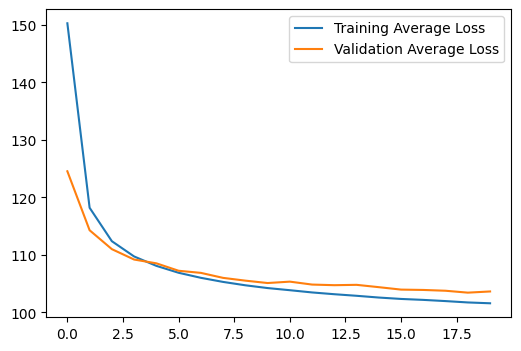

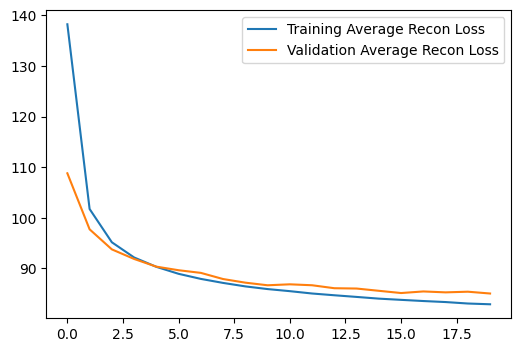

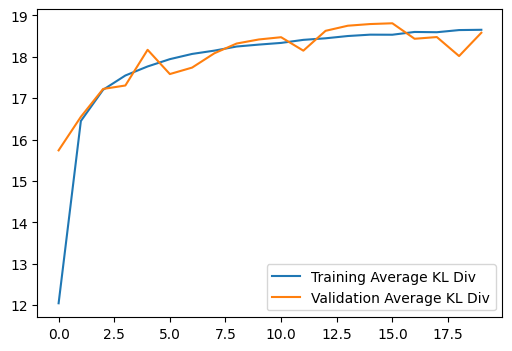

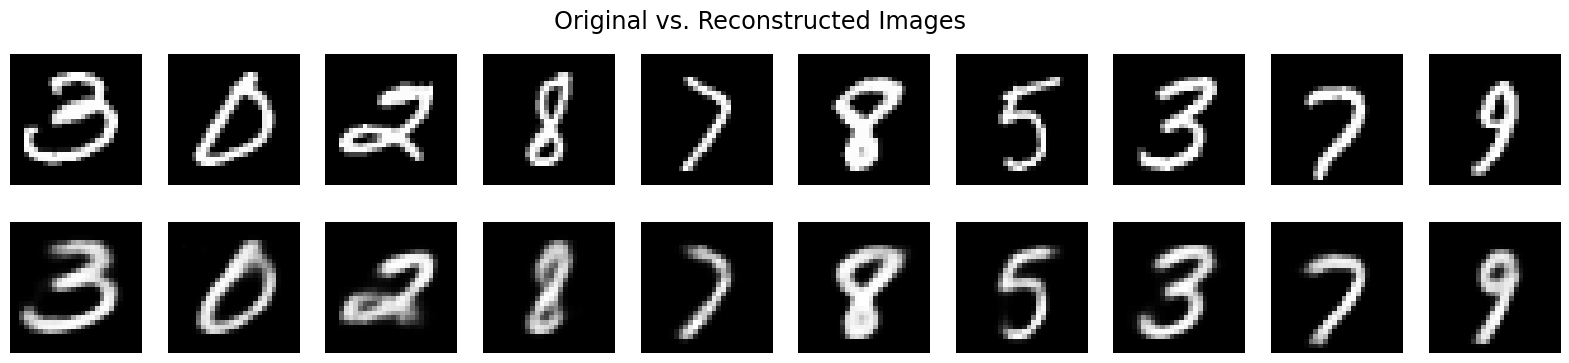

In [22]:
model = VAE(28*28, 32)
optimizer = optim.Adam(model.parameters(), lr=0.001)

results = train_model(model, train_loader, val_loader, optimizer=optimizer, num_epochs=20)
plot_train_graph(results)

show_x_new(model, train_loader)

----------------------------------------
Test Loss:                103.27%
Test Reconstruction Loss: 84.73%
Test KL Divergence:       18.5447
----------------------------------------

Reconstruction Quality:


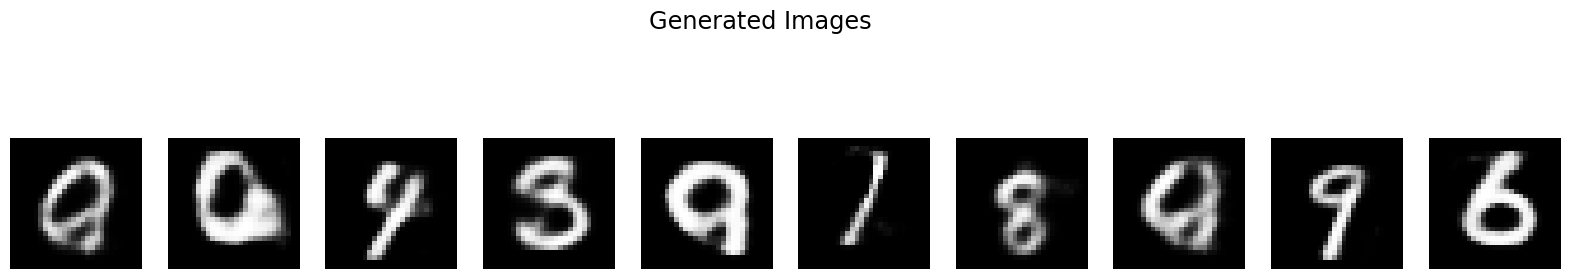

(103.27398702392578, 84.72928736572266, 18.54469972229004)

In [23]:
test_and_report(model, test_loader, 32)

/tmp/ipykernel_3352/245544098.py:177: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  all_means = torch.cat([torch.tensor(l) for l in all_means], dim=0).numpy()
/tmp/ipykernel_3352/245544098.py:178: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  all_labels = torch.cat([torch.tensor(l) for l in all_labels], dim=0).numpy()


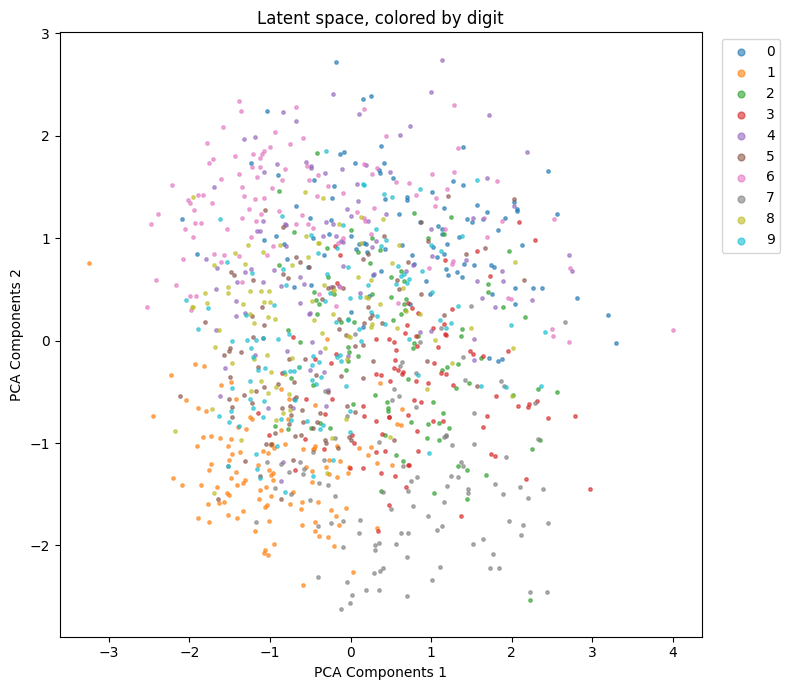

/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


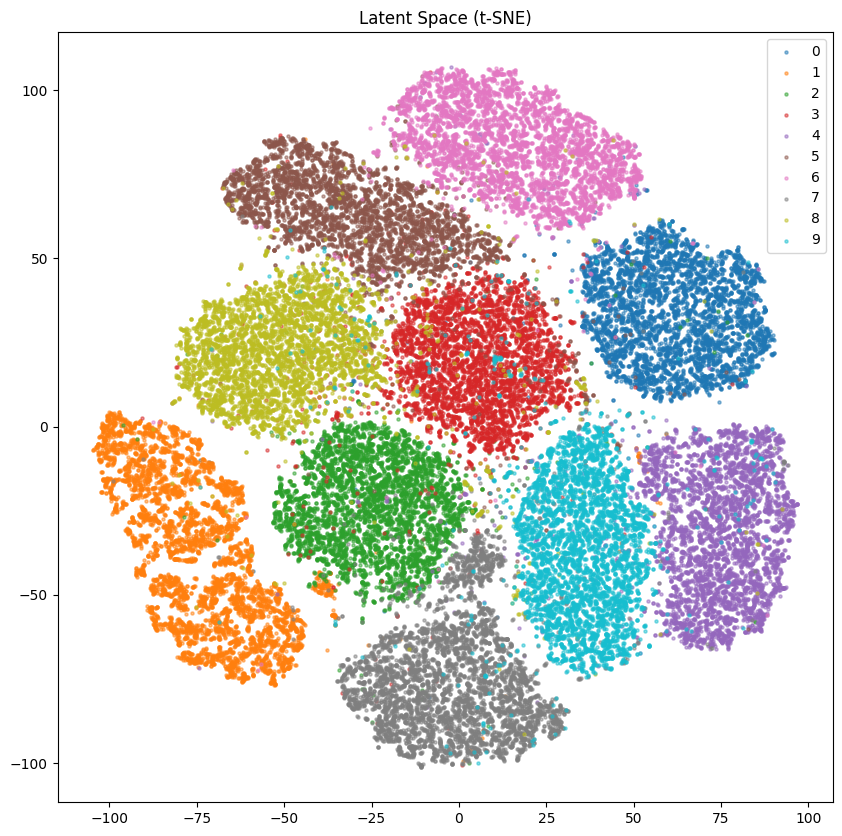

In [24]:
plot_latent_space(model, train_loader, latent_dim=32)
plot_latent_tsne(model, train_loader)

# Task 4.3: Comparing with Doersch’s VAE Implementation

### Architecture Comparison:

**Our Model:** Is designed by constructing a 2-hidden layer MLP:
- Encoder as a fully connected MLP $784 \to 512 \to 256 \to (\mu, \log\sigma^2 \in \mathbb{R}^{128}$) with ReLU activations.
- Decoder also as a fully connected MLP ($128 \to 256 \to 512 \to 784$) with ReLU activations and a terminal Sigmoid.

**Doersch's Model:** A 1-hidden layer MLP:
- Encoder  $784 \to 512 \to \mu, \log\sigma^2 \in \mathbb{R}^d)$ with Tanh activations.
- Decoder $d \to 512 \to 784$) with Tanh activations and a terminal Sigmoid.

Takeaway: Both utilize fully connected feedforward networks rather than convolutional layers, though our model uses a deeper 2-layer hierarchy with ReLU units.

### Output Distribution & Loss Function:

**Exact Match:** Since in MNIST, pixels are mostly black(0) or white(1), thereofre instead of treating as image as an arbitrary grid of numbers the model intercepts each pixel as an independent $x_i$ = 1 (white / inked) or $x_i$ = 0 (Black / Background). Therefore, the normalized pixel intensities can be treated as independent Bernoulli random variables. The decoder uses Sigmoid activation ($\sigma(z)$) as its terminal forces each output value into the continuous range of probability $\hat{x}_i \in [0, 1]$ of each pixel being white, which directly leads to using Binary Cross-Entropy (BCE) as the reconstruction loss.

In compact mathematical form, the probability of observing the target pixel $x_i$ is:$$p_\theta(x_i \mid z) = \hat{x}_i^{x_i} (1 - \hat{x}_i)^{1 - x_i}$$

Both optimize the standard negative ELBO objective combining Binary Cross-Entropy (BCE) reconstruction loss with the analytical Gaussian KL divergence:
    $$\mathcal{L} = \text{BCE}(x_{\text{recon}}, x) + D_{\text{KL}}\big(\mathcal{N}(\mu, \operatorname{diag}(\sigma^2)) \,\parallel\, \mathcal{N}(0, I)\big)$$

### Latent Dimensionality & Comparative Analysis:

**Our Choice & Multi-Run Experimentation:**
  * **Run 1 ($d = 128$):**
    * Test Total Loss = **94.45**
    * Test BCE Loss = **83.37**
    * Test KL Divergence = **11.08 nats**

  * **Run 2 ($d = 32$):**
    * Test Total Loss = **103.76**
    * Test BCE Loss = **85.21**
    * Test KL Divergence = **18.55 nats**

**Doersch's Observations on Latent Space Size:**
* Model may underfit if $d < 4$ limiting model capacity to learn core digit variations.
* Stable middle range in between ($d \approx 10\text{--}128$): allowing model to capture required meaningful distribution manifolds resulting in  robust and stable quality. Thus our choice of $d = 128$ provides ample capacity while the KL term automatically prunes inactive dimensions ($\mu_j \approx 0, \sigma_j^2 \approx 1$).
* Going beyond ($d \gg 1000$) may destabilize gradient optimization in practice despite theoretical robustness.

**Dimension Pruning vs. Information Density:** In $d = 128$, surplus dimensions automatically collapse to the prior ($\mu_j \approx 0, \sigma_j^2 \approx 1$), keeping total KL lower ($11.08$). In $d = 32$, each active dimension carries a higher information load, yielding higher KL divergence ($18.55$).


### Results & Failure Cases:

**Qualitative Alignment:** Both implementations are able to produce recognizable reconstructions with characteristic edge softness due to independent Bernoulli pixel modeling and posterior expectation averaging.

**Prior Sampling:** Random draws $z \sim \mathcal{N}(0, I)$ yield valid, diverse digits alongside occasional ambiguous intermediate forms (e.g., hybrid $4/9$ or $6/1$ shapes) when sampled from boundaries between adjacent class manifolds.